#### Example usage of simulation experiment

In [4]:
import torch
from exp_class import FederatedThompsonSampler
from helper_CMTS import levy, ackley, branin, hartmann_2x2, create_perturbed_f_k

combos = [(1, 2)]

functions = {
    "levy": levy
}

K = 2
repeats = 1

# Storage
resultss = {fn_name: {} for fn_name in functions.keys()}

for fn_name, fn_handle in functions.items():
    for (x_dim, c_dim) in combos:
        t_0 = 5 * (x_dim + c_dim)
        T = t_0 + 2 * (x_dim + c_dim)

        results_indep, results_fd, results_fdrff = [], [], []

        # fixed client functions across repeats
        f_ks = [create_perturbed_f_k(fn_handle, x_dim, c_dim) for _ in range(K)]
        # if you want same function for all clients:
        # f_ks = [fn_handle for _ in range(K)]

        for i in range(repeats):
            seed = 20250717 + i
            print(f"Running {fn_name}, combo=({x_dim},{c_dim}), repeat {i+1}/{repeats}")

            fts = FederatedThompsonSampler(
                fn_handle, x_dim, c_dim, K, T, t_0, f_ks, seed=seed
            )

            fts.reset_data()
            _, _, _, _, regret_indep = fts.run_indep()
            results_indep.append(regret_indep)

            fts.reset_data()
            _, _, _, _, regret_fd = fts.run_fd()
            results_fd.append(regret_fd)

            fts.reset_data()
            _, _, _, _, regret_fdrff = fts.run_fd_rff()
            results_fdrff.append(regret_fdrff)

        # example: print the last regret of first repeat

        resultss[fn_name][(x_dim, c_dim)] = {
            "fd": results_fd,
            "indep": results_indep,
            "fdrff": results_fdrff
        }

Running levy, combo=(1,2), repeat 1/1


Running FMTS_fd: 100%|██████████| 6/6 [00:05<00:00,  1.14it/s]


#### Plot the regret curves

[levy 2-2] Final iteration mean ± std:
  Federated   : 0.0651634 ± 0.0101672
  Independent : 0.0733215 ± 0.00622597
  Random      : 0.0727446 ± 0.00976739
  FTS      : 0.07554 ± 0.00722636
10
10
10
10


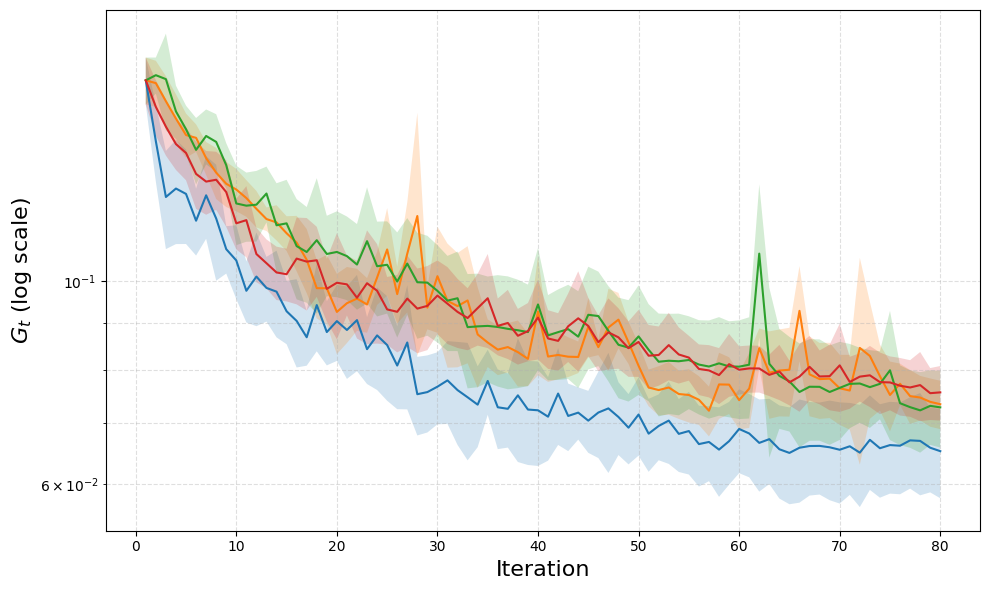

In [ ]:
# ====== Imports ======
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Union

# ====== Helpers ======
def extract_regrets(raw_list: List[Union[dict, list, np.ndarray, torch.Tensor]]) -> torch.Tensor:
    """
    Convert a list like:
      [{0: [...], 1: [...], ...}, {0: [...], 1: [...], ...}, ...]
    into a stacked tensor: (repeats, T) by averaging across clients if dict.
    """
    regrets = []
    for r in raw_list:
        if isinstance(r, dict):  # average across clients
            vals = [torch.tensor(v, dtype=torch.float32) for v in r.values()]
            regrets.append(torch.stack(vals).mean(dim=0))
        elif isinstance(r, (list, np.ndarray, torch.Tensor)):
            regrets.append(torch.tensor(r, dtype=torch.float32))
        else:
            raise TypeError(f"Unexpected type for regret: {type(r)}")
    return torch.stack(regrets)  # shape: (repeats, T)


def t_critical_975(df: int) -> float:
    """
    Return an approximate two-sided 95% t critical (0.975 quantile) for df degrees of freedom.
    Uses a small lookup; falls back to 1.96 for df >= 60.
    """
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042,
        40: 2.021, 60: 2.000
    }
    if df in table:
        return table[df]
    if df < 40:
        # Linear interp between 30 and 40 as a simple, decent approximation
        return table[30] + (table[40] - table[30]) * ((df - 30) / (40 - 30))
    if df < 60:
        # Interp between 40 and 60
        return table[40] + (table[60] - table[40]) * ((df - 40) / (60 - 40))
    # ~Normal
    return 1.96


def ci_for_mean(mean: torch.Tensor, std: torch.Tensor, R: int, level: float = 0.95, use_t: bool = True):
    """
    Build confidence intervals for the mean curve at each t:
       mean ± crit * (std / sqrt(R))
    Returns (lower: np.ndarray, upper: np.ndarray)
    """
    print(R)
    se = (std / np.sqrt(R)).numpy()
    if use_t and R >= 2 and abs(level - 0.95) < 1e-9:
        crit = t_critical_975(R - 1)
    else:
        # Normal-based; for general 'level', use inverse-CDF if you have scipy.
        # Here we default to ~95% if unspecified.
        crit = 1.96 if abs(level - 0.95) < 1e-9 else 1.96
    m = mean.numpy()
    return (m - crit * se, m + crit * se)


def quantile_band(regret_all: torch.Tensor, q_low=0.10, q_high=0.90):
    """
    Return (q_low, median, q_high) across repeats at each t.
    regret_all: (repeats, T)
    """
    arr = regret_all.numpy()
    ql, q50, qh = np.quantile(arr, [q_low, 0.5, q_high], axis=0)
    return ql, q50, qh


# ====== Main plotting routine ======
def plot_regret_means_and_ci(
    results: Dict[str, Dict[Tuple[int, int], Dict[str, List]]],
    plot_combos: Dict[str, List[Tuple[int, int]]],
    use_mean_ci: bool = True,          # True: CI for the mean; False: variability band (mean±std)
    level: float = 0.95,
    also_show_quantiles: bool = False, # overlays dashed median with 10–90% ribbon
    log_eps: float = 1e-12
):
    """
    For each (fn_name, x_dim, c_dim), compute mean regret and plot CI bands.
    """
    for fn_name, combos in plot_combos.items():
        for (x_dim, c_dim) in combos:
            data = results[fn_name][(x_dim, c_dim)]

            # Extract regrets (averaged across clients per repeat)
            regret_fd_all = extract_regrets(data["fd"])    # (repeats, T)
            regret_indep_all = extract_regrets(data["indep"])
            regret_rand_all = extract_regrets(data["rand"])
            regret_fts_all = extract_regrets(data["fts"])
            # cumu
            # ====== make them cumulative ======
            #regret_fd_all    = regret_fd_all.cumsum(dim=1)
            #regret_indep_all = regret_indep_all.cumsum(dim=1)
            #regret_rand_all  = regret_rand_all.cumsum(dim=1)
            #regret_fts_all   = regret_fts_all.cumsum(dim=1)
            
            #regret_fd_all    = regret_fd_all[:, 5:]
            #regret_indep_all = regret_indep_all[:, 5:]
            #regret_rand_all  = regret_rand_all[:, 5:]
            #regret_fts_all   = regret_fts_all[:, 5:]
            R = regret_fd_all.shape[0]  # number of repeats
            T = regret_fd_all.shape[1]
            x = np.arange(1, T + 1)

            # Means & Stds across repeats (per t)
            mean_fd, std_fd = regret_fd_all.mean(dim=0), regret_fd_all.std(dim=0)
            mean_ind, std_ind = regret_indep_all.mean(dim=0), regret_indep_all.std(dim=0)
            mean_rnd, std_rnd = regret_rand_all.mean(dim=0), regret_rand_all.std(dim=0)
            mean_fts, std_fts = regret_fts_all.mean(dim=0), regret_fts_all.std(dim=0)

            # --- Print final-iteration stats ---
            print(f"[{fn_name} {x_dim}-{c_dim}] Final iteration mean ± std:")
            print(f"  Federated   : {mean_fd[-1].item():.6g} ± {std_fd[-1].item():.6g}")
            print(f"  Independent : {mean_ind[-1].item():.6g} ± {std_ind[-1].item():.6g}")
            print(f"  Random      : {mean_rnd[-1].item():.6g} ± {std_rnd[-1].item():.6g}")
            print(f"  FTS      : {mean_fts[-1].item():.6g} ± {std_fts[-1].item():.6g}")

            # --- Central curves (means) ---
            m_fd_np  = np.clip(mean_fd.numpy(),  log_eps, None)
            m_ind_np = np.clip(mean_ind.numpy(), log_eps, None)
            m_rnd_np = np.clip(mean_rnd.numpy(), log_eps, None)
            m_fts_np = np.clip(mean_fts.numpy(), log_eps, None)

            # --- Bands ---
            if use_mean_ci:
                # Confidence intervals for the mean (mean ± crit * SE)
                l_fd, u_fd   = ci_for_mean(mean_fd,  std_fd,  R, level=level, use_t=True)
                l_ind, u_ind = ci_for_mean(mean_ind, std_ind, R, level=level, use_t=True)
                l_rnd, u_rnd = ci_for_mean(mean_rnd, std_rnd, R, level=level, use_t=True)
                l_fts, u_fts = ci_for_mean(mean_fts, std_fts, R, level=level, use_t=True)

                band_label = f"{int(level*100)}% CI (mean)"
            else:
                # Variability bands across runs (mean ± 1·std)
                l_fd,   u_fd   = (mean_fd - std_fd).numpy(),  (mean_fd + std_fd).numpy()
                l_ind,  u_ind  = (mean_ind - std_ind).numpy(), (mean_ind + std_ind).numpy()
                l_rnd,  u_rnd  = (mean_rnd - std_rnd).numpy(), (mean_rnd + std_rnd).numpy()
                l_fts,  u_fts  = (mean_fts - std_fts).numpy(), (mean_fts + std_fts).numpy()

                band_label = "Mean ± 1 Std (runs)"

            # clip to be positive for log scale
            l_fd_np  = np.clip(l_fd,  log_eps, None);  u_fd_np  = np.clip(u_fd,  log_eps, None)
            l_ind_np = np.clip(l_ind, log_eps, None);  u_ind_np = np.clip(u_ind, log_eps, None)
            l_rnd_np = np.clip(l_rnd, log_eps, None);  u_rnd_np = np.clip(u_rnd, log_eps, None)
            l_fts_np = np.clip(l_fts, log_eps, None);  u_fts_np = np.clip(u_fts, log_eps, None)

            # --- Plot ---
            plt.figure(figsize=(10, 6))

            # Federated
            plt.plot(x, m_fd_np, label="Federated")
            plt.fill_between(x, l_fd_np, u_fd_np, alpha=0.2, label=band_label)

            # Independent
            plt.plot(x, m_ind_np, label="Independent")
            plt.fill_between(x, l_ind_np, u_ind_np, alpha=0.2)

            # Random
            plt.plot(x, m_rnd_np, label="Random")
            plt.fill_between(x, l_rnd_np, u_rnd_np, alpha=0.2)
            plt.plot(x, m_fts_np, label="FTS")
            plt.fill_between(x, l_fts_np, u_fts_np, alpha=0.2)
            #plt.plot(x, m_opt_np, label="Optimal")
            #plt.fill_between(x, l_opt_np, u_opt_np, alpha=0.2)

            # Optional: overlay quantile ribbons to show variability (dashed medians)
            if also_show_quantiles:
                ql_fd, q50_fd, qh_fd = quantile_band(regret_fd_all, 0.1, 0.9)
                ql_ind, q50_ind, qh_ind = quantile_band(regret_indep_all, 0.1, 0.9)
                ql_rnd, q50_rnd, qh_rnd = quantile_band(regret_rand_all, 0.1, 0.9)
                ql_fts, q50_fts, qh_fts = quantile_band(regret_rand_all, 0.1, 0.9)

                plt.fill_between(x, np.clip(ql_fd,  log_eps, None),
                                    np.clip(qh_fd,  log_eps, None), alpha=0.12, linewidth=0)
                plt.fill_between(x, np.clip(ql_ind, log_eps, None),
                                    np.clip(qh_ind, log_eps, None), alpha=0.12, linewidth=0)
                plt.fill_between(x, np.clip(ql_rnd, log_eps, None),
                                    np.clip(qh_rnd, log_eps, None), alpha=0.12, linewidth=0)
                plt.fill_between(x, np.clip(ql_fts, log_eps, None),
                                    np.clip(qh_fts, log_eps, None), alpha=0.12, linewidth=0)
                #plt.fill_between(x, np.clip(ql_opt[:80], log_eps, None),
                #                    np.clip(qh_opt[:80], log_eps, None), alpha=0.12, linewidth=0)
                plt.plot(x, np.clip(q50_fd,  log_eps, None), linestyle="--", linewidth=1)
                plt.plot(x, np.clip(q50_ind, log_eps, None), linestyle="--", linewidth=1)
                plt.plot(x, np.clip(q50_rnd, log_eps, None), linestyle="--", linewidth=1)
                plt.plot(x, np.clip(q50_fts, log_eps, None), linestyle="--", linewidth=1)
                #plt.plot(x, np.clip(q50_opt, log_eps, None), linestyle="--", linewidth=1)
            plt.xlabel("Iteration", size = 16)
            plt.ylabel(f'$G_t$ (log scale)', size = 16)
            band_desc = "95% CI for mean" if use_mean_ci else "Mean ± 1 Std"
            #plt.title(f"{fn_name.capitalize()} ({x_dim}-{c_dim})\n{band_desc} over {R} repeats")
            #plt.legend()
            plt.yscale('log')
            plt.grid(True, which="both", linestyle="--", alpha=0.4)
            plt.tight_layout()
            plt.show()
            


# ====== Example call ======
# Your existing structure:
# plot_combos = { "ackley": [(2,1), (1,2), (2,2), (1,3)] }
# results = { "ackley": { (2,1): {"fd": [...], "indep": [...], "rand": [...]}, ... } }

def load_single_results_csv(path: str):
    import pandas as pd
    df = pd.read_csv(path)

    fn_name = str(df["function"].iloc[0])
    x_dim = int(df["x_dim"].iloc[0])
    c_dim = int(df["c_dim"].iloc[0])
    results = {fn_name: {(x_dim, c_dim): {}}}

    for method, dmf in df.groupby("method"):
        rebuilt = []
        for rep, drep in dmf.groupby("repeat"):
            if (dmf["client"] != -1).any():
                client_dict = {int(cid): grp.sort_values("t")["regret"].tolist()
                               for cid, grp in drep.groupby("client")}
                rebuilt.append(client_dict)
            else:
                seq = drep.sort_values("t")["regret"].tolist()
                rebuilt.append(seq)
        results[fn_name][(x_dim, c_dim)][method] = rebuilt

    return results

results_back = load_single_results_csv("exp_res/levy_2-2.csv")

plot_regret_means_and_ci(
    results=results_back,
    plot_combos={"levy": [(2,2)]},
    use_mean_ci=True,          # change to False for mean ± std
    level=0.95,
    also_show_quantiles=False, # set True to overlay 10–90% ribbons + median
    log_eps=1e-12
)